## Intervention on Restatement during GPT-OSS' Vanilla Reasoning

In [1]:
%load_ext autoreload
%autoreload 2

### Overview

Legacy file performing token patching, activation patching, and steering for the vanilla prompt where the GPT-OSS 20B model is given no developer instruction to produce CoT step by step.

### Set-up

Imports intervention primitives from `_intervention` and dataset/prompt helpers from `_dataset`/`_prompt`, checks GPU availability, and loads the vanilla (non-stepwise) GPT-OSS model/tokenizer via `_util.load_OSS()`.

In [ ]:
import torch
import gc
import pandas as pd
from tqdm import tqdm
import random

import sys
sys.path.append("src")
import _util
import _dataset
import _prompt
from _intervention import prepare_batch_multitoken_intervention, batch_intervene, get_attention_freeze_hooks, forward_with_cache

In [3]:
_util.print_GPU_availbility()

CUDA is available: True
Available devices:
  GPU 0: NVIDIA RTX A5000
|===========================================================================|
|                  PyTorch CUDA memory summary, device ID 0                 |
|---------------------------------------------------------------------------|
|            CUDA OOMs: 0            |        cudaMalloc retries: 0         |
|===========================================================================|
|        Metric         | Cur Usage  | Peak Usage | Tot Alloc  | Tot Freed  |
|---------------------------------------------------------------------------|
| Allocated memory      |      0 B   |      0 B   |      0 B   |      0 B   |
|       from large pool |      0 B   |      0 B   |      0 B   |      0 B   |
|       from small pool |      0 B   |      0 B   |      0 B   |      0 B   |
|---------------------------------------------------------------------------|
| Active memory         |      0 B   |      0 B   |      0 B   |      0 B

In [4]:
model_type = "GPT-OSS"
model, tokenizer = _util.load_OSS()

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

## Prompt Templates

Defines the raw Harmony-format system/user/assistant string templates used to hand-construct vanilla addition prompts (no explicit stepwise instruction) and their intervened variants (`num2_intervened`), then builds `patch_ds`, a DataFrame of 256 base/source number pairs with the corresponding `base_prompt`/`source_prompt`/`intervened_prompt` strings.

In [ ]:
system_prompt = '''<|start|>system<|message|>You are ChatGPT, a large language model trained by OpenAI.
Knowledge cutoff: 2024-06
Current date: 2025-06-28

Reasoning: high

# Valid channels: analysis, commentary, final. Channel must be included for every message.<|end|>'''

user_question = '''<|start|>user<|message|>What is {num1}+{num2}?<|end|><|start|>assistant'''

reasoning = '''<|start|>assistant<|channel|>analysis<|message|>The user asks: "What is {num1}+{num2}?" This is a simple arithmetic question. {num1}+{num2}='''

reasoning = '''<|start|>assistant<|channel|>analysis<|message|>We need to answer the question: "What is {num1}+{num2_intervened}?" The answer is '''

reasoning = '''<|start|>assistant<|channel|>analysis<|message|>The user asks: "What is {num1}+{num2}?" This is a simple arithmetic question. The answer is '''

result = '''{sum}. The user likely expects a straightforward answer. There's no trick. So respond with "'''
result2 = '''{sum}". Possibly add a brief explanation. But the user didn't ask for explanation. Just answer. So answer: '''
result3 = '''{sum}.'''
final_output = '''<|end|><|start|>assistant<|channel|>final<|message|>'''

In [50]:
random.seed(42)

add_ds = _dataset.create_h2_dataset(num_digits=2, num_samples=256)

In [7]:
# from openai_harmony import (
#     Author,
#     Conversation,
#     DeveloperContent,
#     HarmonyEncodingName,
#     Message,
#     Role,
#     SystemContent,
#     ToolDescription,
#     load_harmony_encoding,
#     ReasoningEffort
# )
 
# encoding = load_harmony_encoding(HarmonyEncodingName.HARMONY_GPT_OSS)
 
# system_message = (
#     SystemContent.new()
#         .with_reasoning_effort(ReasoningEffort.HIGH)
#         .with_conversation_start_date("2025-06-28")
# )
 
# convo = Conversation.from_messages(
#     [
#         Message.from_role_and_content(Role.SYSTEM, system_message),
#         Message.from_role_and_content(Role.USER, "What is 4153+7285?"),
#     ]
# )
 
# tokens = encoding.render_conversation_for_completion(convo, Role.ASSISTANT)
# print(tokenizer.decode(tokens))
# print(tokenizer.convert_ids_to_tokens(tokens))

In [53]:
for add_ds_entry in add_ds[:10]:
    input_prompt = system_prompt + user_question.format(num1=add_ds_entry["base_1_num"], num2=add_ds_entry["base_2_num"])
    tokens = tokenizer(input_prompt, return_tensors="pt").to(model.device)
    # Generate for the entire batch
    generations = model.generate(
        tokens.input_ids,
        attention_mask=tokens.attention_mask,
        max_new_tokens=512,
        do_sample=False,
        pad_token_id=tokenizer.pad_token_id,
    )
    print(tokenizer.decode(generations[0]))

<|start|>system<|message|>You are ChatGPT, a large language model trained by OpenAI.
Knowledge cutoff: 2024-06
Current date: 2025-06-28

Reasoning: high

# Valid channels: analysis, commentary, final. Channel must be included for every message.<|end|><|start|>user<|message|>What is 20+54?<|end|><|start|>assistant<|channel|>analysis<|message|>The user asks: "What is 20+54?" It's a simple arithmetic addition. 20 + 54 = 74. So answer: 74.<|end|><|start|>assistant<|channel|>final<|message|>20 + 54 = **74**<|return|>
<|start|>system<|message|>You are ChatGPT, a large language model trained by OpenAI.
Knowledge cutoff: 2024-06
Current date: 2025-06-28

Reasoning: high

# Valid channels: analysis, commentary, final. Channel must be included for every message.<|end|><|start|>user<|message|>What is 31+92?<|end|><|start|>assistant<|channel|>analysis<|message|>The user asks: "What is 31+92?" They want the sum. 31 + 92 = 123. So answer: 123. Probably just answer.<|end|><|start|>assistant<|channel|

KeyboardInterrupt: 

In [42]:
def get_prompt(num1, num2):
    return (system_prompt + user_question + reasoning).format(num1=num1, num2=num2, num2_intervened=num2)

def get_intervened_prompt(num1, num2, source_num2):
    return (system_prompt + user_question + reasoning).format(num1=num1, num2=num2, num2_intervened=source_num2)

In [43]:
prompt = get_prompt(add_ds[0]["base_1_num"], add_ds[0]["base_2_num"])
print(prompt)
prompt = get_intervened_prompt(add_ds[0]["base_1_num"], add_ds[0]["base_2_num"], add_ds[0]["source_2_num"])
print(prompt)

<|start|>system<|message|>You are ChatGPT, a large language model trained by OpenAI.
Knowledge cutoff: 2024-06
Current date: 2025-06-28

Reasoning: high

# Valid channels: analysis, commentary, final. Channel must be included for every message.<|end|><|start|>user<|message|>What is 20+54?<|end|><|start|>assistant<|channel|>analysis<|message|>We need to answer the question: "What is 20+54?" The answer is 
<|start|>system<|message|>You are ChatGPT, a large language model trained by OpenAI.
Knowledge cutoff: 2024-06
Current date: 2025-06-28

Reasoning: high

# Valid channels: analysis, commentary, final. Channel must be included for every message.<|end|><|start|>user<|message|>What is 20+54?<|end|><|start|>assistant<|channel|>analysis<|message|>We need to answer the question: "What is 20+44?" The answer is 


In [45]:
patch_ds = []
for add_ds_entry in add_ds:
    patch_ds.append([add_ds_entry["base_1_num"], add_ds_entry["base_2_num"], add_ds_entry["source_1_num"], add_ds_entry["source_2_num"], add_ds_entry["base_sum"], add_ds_entry["source_sum"], get_prompt(add_ds_entry["base_1_num"], add_ds_entry["base_2_num"]), get_prompt(add_ds_entry["source_1_num"], add_ds_entry["source_2_num"]), get_intervened_prompt(add_ds_entry["base_1_num"], add_ds_entry["base_2_num"], add_ds_entry["source_2_num"])])

# Convert patch_ds to pandas DataFrame
patch_ds = pd.DataFrame(patch_ds, columns=['base_1_num', 'base_2_num', 'source_1_num', 'source_2_num', 'base_sum', 'source_sum', 'base_prompt', 'source_prompt', 'intervened_prompt'])

In [ ]:
# for i, row in patch_ds.iterrows():
#     tokens = tokenizer(row["base_prompt"], return_tensors="pt").to(model.device)
#     print(list(enumerate(tokenizer.convert_ids_to_tokens(tokens["input_ids"][0]))))
#     print(len(tokens["input_ids"][0]))


[(0, '<|start|>'), (1, 'system'), (2, '<|message|>'), (3, 'You'), (4, 'Ġare'), (5, 'ĠChat'), (6, 'GPT'), (7, ','), (8, 'Ġa'), (9, 'Ġlarge'), (10, 'Ġlanguage'), (11, 'Ġmodel'), (12, 'Ġtrained'), (13, 'Ġby'), (14, 'ĠOpen'), (15, 'AI'), (16, '.Ċ'), (17, 'Knowledge'), (18, 'Ġcutoff'), (19, ':'), (20, 'Ġ'), (21, '202'), (22, '4'), (23, '-'), (24, '06'), (25, 'Ċ'), (26, 'Current'), (27, 'Ġdate'), (28, ':'), (29, 'Ġ'), (30, '202'), (31, '5'), (32, '-'), (33, '06'), (34, '-'), (35, '28'), (36, 'ĊĊ'), (37, 'Reason'), (38, 'ing'), (39, ':'), (40, 'Ġhigh'), (41, 'ĊĊ'), (42, '#'), (43, 'ĠValid'), (44, 'Ġchannels'), (45, ':'), (46, 'Ġanalysis'), (47, ','), (48, 'Ġcommentary'), (49, ','), (50, 'Ġfinal'), (51, '.'), (52, 'ĠChannel'), (53, 'Ġmust'), (54, 'Ġbe'), (55, 'Ġincluded'), (56, 'Ġfor'), (57, 'Ġevery'), (58, 'Ġmessage'), (59, '.'), (60, '<|end|>'), (61, '<|start|>'), (62, 'user'), (63, '<|message|>'), (64, 'What'), (65, 'Ġis'), (66, 'Ġ'), (67, '20'), (68, '+'), (69, '54'), (70, '?'), (71, '<|en

### Intervention

Two variants of the intervention at the second-addend token position (`tok_pos_list=[90]`): (1) plain text substitution — generating directly from `intervened_prompt` (source number spliced into the string, no activation patching), written to `vanilla_patching/generation_h2.csv`; (2) real activation patching at a single layer (`layer=0`) via `prepare_batch_multitoken_intervention`, scoring generations by whether they contain `base_sum` (`is_factual`) or `source_sum` (`is_counterfactual`), written to `vanilla_patching/token_patching.csv`.

In [46]:
tok_pos_list = [90]

header = ['layer'] + list(patch_ds.columns) + ['intervention_id', 'generated_text', 'is_factual', 'is_counterfactual']
filepath = _util.create_csv_file(f"experiments/activation_intervention/output/{model_type}/vanilla_patching", f"generation_h2.csv", header, overwrite=True)


batch_size = 24

for i in tqdm(range(0, len(patch_ds), batch_size)):
    torch.cuda.empty_cache()
    gc.collect()
    batch_rows = patch_ds.iloc[i:i+batch_size]

    # Prepare batch of intervention prompts
    intervention_prompts = batch_rows['intervened_prompt'].tolist()
    
    # Tokenize all prompts in the batch
    tokenized_inputs = tokenizer(intervention_prompts, add_special_tokens=False, return_tensors="pt", padding=True, padding_side="left").to(model.device)
    
    # Generate for the entire batch
    generations = model.generate(
        tokenized_inputs.input_ids,
        attention_mask=tokenized_inputs.attention_mask,
        max_new_tokens=512,
        do_sample=False,
        pad_token_id=tokenizer.pad_token_id,
    )
    
    # Process each generated text in the batch
    for j, (_, row) in enumerate(batch_rows.iterrows()):
        intervention_prompt = intervention_prompts[j]
        generated_text = tokenizer.decode(generations[j]).replace(intervention_prompt, "").replace(tokenizer.pad_token[-1], "")
        _util.write_to_csv(filepath, row.to_list() + [intervention_prompt, generated_text])

  0%|                                                                                                                           | 0/11 [00:00<?, ?it/s]

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 11/11 [06:26<00:00, 35.18s/it]


In [ ]:
tok_pos_list = [90]

header = ['layer'] + list(patch_ds.columns) + ['intervention_id', 'generated_text', 'is_factual', 'is_counterfactual']
filepath = _util.create_csv_file(f"experiments/activation_intervention/output/{model_type}/vanilla_patching", f"token_patching.csv", header, overwrite=True)


for layer in range(1):
    batch_size = 24

    for i in tqdm(range(0, len(patch_ds), batch_size)):
        torch.cuda.empty_cache()
        gc.collect()
        batch_rows = patch_ds.iloc[i:i+batch_size]

        tokens, source_tokens, hook = prepare_batch_multitoken_intervention(model, tokenizer, layer, tok_pos_list, batch_rows['base_prompt'].tolist(), batch_rows['source_prompt'].tolist())
        input_length = tokens["input_ids"].shape[1]

        for j in range(2):
            attention_freeze_hooks = [] # get_attention_freeze_hooks(model, source_tokens)
            with torch.no_grad():
                output = batch_intervene(model, tokens["input_ids"], attention_freeze_hooks + [hook], attention_mask=tokens["attention_mask"]) # attention_freeze_hooks + 
            pred_toks = output.logits[:,-1,:].argmax(dim=-1)
            tokens["input_ids"] = torch.cat([tokens["input_ids"], pred_toks.unsqueeze(-1)], dim=1)
            source_tokens["input_ids"] = torch.cat([source_tokens["input_ids"], pred_toks.unsqueeze(-1)], dim=1)
            del output
        
        for j, (_, row) in enumerate(batch_rows.iterrows()):
            generated_text = tokenizer.decode(tokens["input_ids"][j,input_length:]).replace(tokenizer.pad_token[-1], "")
            is_factual = str(row["base_sum"]) in generated_text
            is_counterfactual = str(row["source_sum"]) in generated_text
            _util.write_to_csv(filepath, [layer] + row.to_list() + [8, generated_text, is_factual, is_counterfactual])

        del tokens, hook
        torch.cuda.empty_cache()
        gc.collect()

  0%|                                                                             | 0/11 [00:00<?, ?it/s]

100%|████████████████████████████████████████████████████████████████████| 11/11 [01:41<00:00,  9.27s/it]


### Representation Steering: Backtracking Direction

Caches layer-16 residual-stream activations at `tok_pos_list=[90]` for natural prompts vs. prompts patched at `intervention_ids=[8]` (via `forward_with_cache`), then projects the mean natural-vs-intervened activation difference onto a precomputed `backtracking` steering vector (`steering_vectors_gpt-oss-20b.pt`, layer 16) using cosine similarity and scalar projection, to check whether patching the second addend nudges the residual stream along that known direction.

In [16]:
tok_pos_list = [90]
intervention_ids = [8]
LAYER = 16

batch_size = 24

natural_activation_sum = torch.zeros(2880).to("cuda:4")
intervened_activation_sum = torch.zeros(2880).to("cuda:4")

for i in tqdm(range(0, len(patch_ds), batch_size)):
    torch.cuda.empty_cache()
    gc.collect()
    batch_rows = patch_ds.iloc[i:i+batch_size]

    tokens = tokenizer(batch_rows['base_prompt'].tolist(), add_special_tokens=False, return_tensors="pt", padding=True, padding_side="left").to(model.device)

    _, cache = forward_with_cache(model, tokens["input_ids"], attention_mask=tokens["attention_mask"])
    activations = cache[f"model.layers.{LAYER}"][:,tok_pos_list,:]
    natural_activation_sum = natural_activation_sum + activations.sum(dim=0).sum(dim=0)
    
    intervention_prompts = [_prompt.get_intervened_prompt(intervention_ids, row['base_prompt'], row['source_prompt']) for _, row in batch_rows.iterrows()]
    intervened_tokens = tokenizer(intervention_prompts, add_special_tokens=False, return_tensors="pt", padding=True, padding_side="left").to(model.device)

    _, intervened_cache = forward_with_cache(model, intervened_tokens["input_ids"], attention_mask=intervened_tokens["attention_mask"])
    intervened_activations = intervened_cache[f"model.layers.{LAYER}"][:,tok_pos_list,:]
    intervened_activation_sum = intervened_activation_sum + intervened_activations.sum(dim=0).sum(dim=0)

    del tokens, intervened_tokens, cache, intervened_cache
    torch.cuda.empty_cache()
    gc.collect()

mean_natural_activation = natural_activation_sum / len(patch_ds)
mean_intervened_activation = intervened_activation_sum / len(patch_ds)

100%|████████████████████████████████████████████████████████████████████| 11/11 [00:37<00:00,  3.40s/it]


In [17]:
steering_vectors = torch.load("experiments/activation_intervention/steering_vectors_gpt-oss-20b.pt")
steering_vector = steering_vectors["backtracking"]["mean"][LAYER].to("cuda:4")
print(torch.nn.functional.cosine_similarity(steering_vector, mean_intervened_activation - mean_natural_activation, dim=0))
print(torch.nn.functional.cosine_similarity(steering_vector, mean_natural_activation, dim=0))
print(torch.nn.functional.cosine_similarity(steering_vector, mean_intervened_activation, dim=0))

scalar_projection = torch.dot(mean_intervened_activation - mean_natural_activation, steering_vector) / torch.norm(steering_vector)
print(scalar_projection)
print(scalar_projection / torch.norm(steering_vector))
print(torch.norm(steering_vector))
print(torch.norm(mean_intervened_activation - mean_natural_activation))
print(torch.norm(mean_intervened_activation))
print(torch.norm(mean_natural_activation))

tensor(0.0614, device='cuda:4')
tensor(0.8107, device='cuda:4')
tensor(0.7898, device='cuda:4')
tensor(144.1389, device='cuda:4')
tensor(0.0468, device='cuda:4')
tensor(3078.5500, device='cuda:4')
tensor(2345.6763, device='cuda:4')
tensor(3695.2791, device='cuda:4')
tensor(3422.5361, device='cuda:4')


### Layer-wise vs. Frozen-Attention Comparison (external results)

Reads a previously computed layer-sweep result file (`vanilla_layer/2_digit_restatement_layerwise.csv`, produced by a separate run) and plots the per-layer factual/counterfactual response proportions next to a hardcoded frozen-attention baseline point (`0.7615`) for comparison.

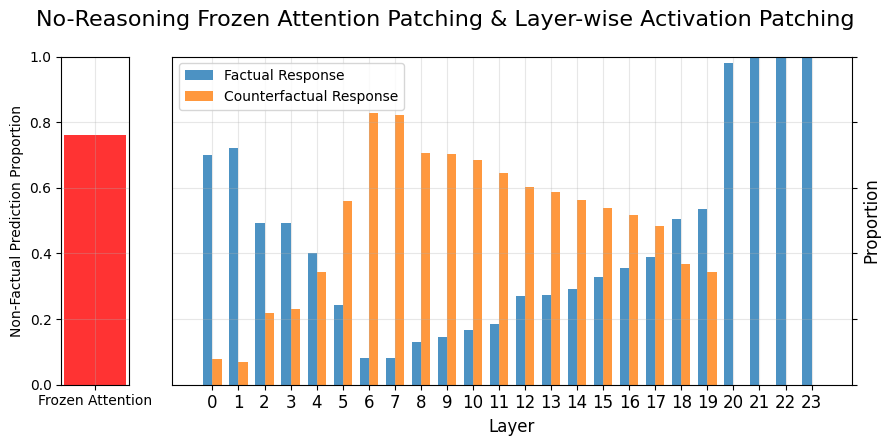

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the CSV file
df = pd.read_csv("/users/dkang33/arithmetic-reasoning-causality/experiments/activation_intervention/output/GPT-OSS_stepwise/vanilla_layer/2_digit_restatement_layerwise.csv")

# Group by layer and calculate the mean of is_factual and is_counterfactual
layer_stats = df.groupby('layer')[['is_factual', 'is_counterfactual']].mean()

# Create subplots with different widths
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 4.5), gridspec_kw={'width_ratios': [1, 10]}, sharey=True)

# Left plot: Frozen Attention
ax1.bar(['Frozen Attention'], [0.7615], width=0.125, alpha=0.8, color='red')
ax1.set_ylim(0, 1)
ax1.grid(True, alpha=0.3)
ax1.set_ylabel('Non-Factual Prediction Proportion', fontsize=10)

# Right plot: Layer-wise analysis
x = range(len(layer_stats.index))
width = 0.35

ax2.bar([i - width/2 for i in x], layer_stats['is_factual'], width, label='Factual Response', alpha=0.8)
ax2.bar([i + width/2 for i in x], layer_stats['is_counterfactual'], width, label='Counterfactual Response', alpha=0.8)

ax2.set_xlabel('Layer', fontsize=12)
ax2.set_ylabel('Proportion', fontsize=12)
ax2.set_xticks(x)
ax2.set_xticklabels(layer_stats.index, fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 1)
ax2.yaxis.set_label_position("right")
ax2.yaxis.tick_right()

# Overall title
fig.suptitle('No-Reasoning Frozen Attention Patching & Layer-wise Activation Patching', fontsize=16)

plt.tight_layout()
plt.show()


### All-Layer Patching Sweep

Builds one patching hook per layer (`range(len(model.model.layers))`) at `tok_pos_list=[90]` and applies all of them together in a single forward pass — i.e. patches every layer simultaneously rather than cumulatively — then greedily decodes 2 tokens. Results (with `is_factual`/`is_counterfactual` flags) are appended to `vanilla_layer/2_digit_restatement_all_layer.csv`.

In [ ]:
tok_pos_list = [90]

header = list(patch_ds.columns) + ['generated_text', 'is_factual', 'is_counterfactual']
filepath = _util.create_csv_file(f"experiments/activation_intervention/output/{model_type}/vanilla_layer", f"2_digit_restatement_all_layer.csv", header, overwrite=False)

batch_size = 24
for i in tqdm(range(0, len(patch_ds), batch_size)):
    torch.cuda.empty_cache()
    gc.collect()
    batch_rows = patch_ds.iloc[i:i+batch_size]
    
    hooks = []
    for layer in range(len(model.model.layers)):
        tokens, _, hook = prepare_batch_multitoken_intervention(model, tokenizer, layer, tok_pos_list, batch_rows['base_prompt'].tolist(), batch_rows['source_prompt'].tolist())
        hooks.append(hook)
    input_length = tokens["input_ids"].shape[1]

    for j in range(2):
        # attention_freeze_hooks = get_attention_freeze_hooks(model, tokens)
        with torch.no_grad():
            output = batch_intervene(model, tokens["input_ids"], hooks, attention_mask=tokens["attention_mask"]) # attention_freeze_hooks + 
        pred_toks = output.logits[:,-1,:].argmax(dim=-1)
        tokens["input_ids"] = torch.cat([tokens["input_ids"], pred_toks.unsqueeze(-1)], dim=1)
        del output
    
    for j, (_, row) in enumerate(batch_rows.iterrows()):
        generated_text = tokenizer.decode(tokens["input_ids"][j,input_length:]).replace(tokenizer.pad_token[-1], "")
        is_factual = str(row["base_sum"]) in generated_text
        is_counterfactual = str(row["source_sum"]) in generated_text
        _util.write_to_csv(filepath, row.to_list() + [generated_text, is_factual, is_counterfactual])

    del tokens, hook
    torch.cuda.empty_cache()
    gc.collect()

100%|█████████████████████████████████████████████████████████████████████████████████| 11/11 [09:58<00:00, 54.40s/it]


### All-Layer Sweep Analysis

Reads `2_digit_restatement_all_layer.csv` back in, computes per-layer factual vs. counterfactual percentages, and plots them as a bar chart for comparison.

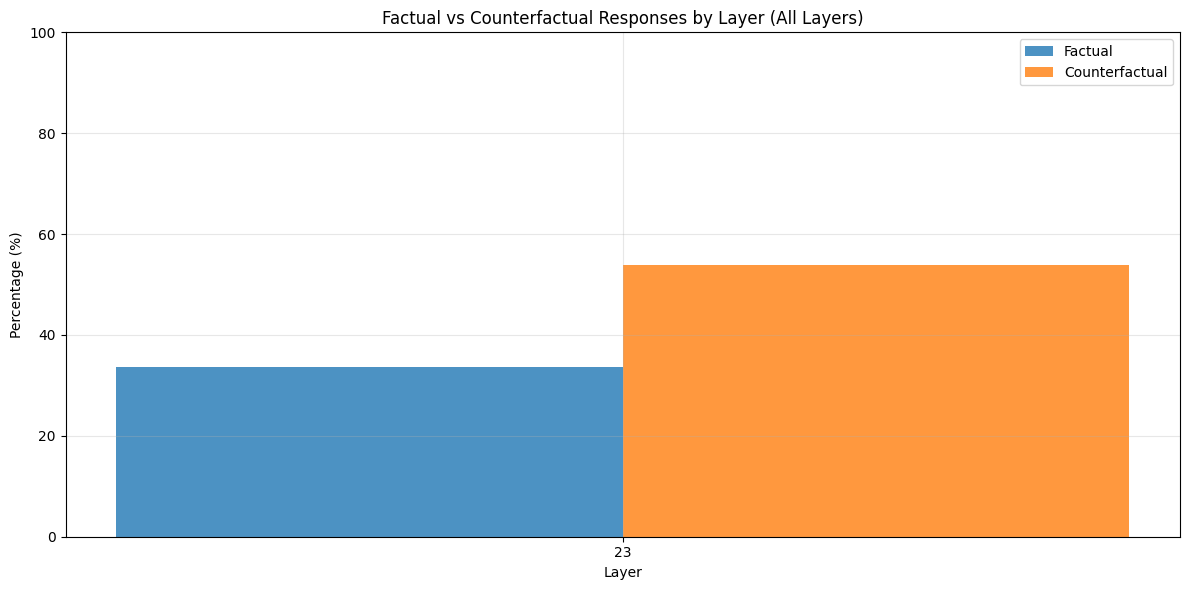

Summary Statistics:
       factual_percentage  counterfactual_percentage
layer                                               
23               33.59375                   53.90625


In [18]:
import numpy as np

# Read the results and analyze factual vs counterfactual responses
results_df = pd.read_csv("experiments/activation_intervention/output/GPT-OSS/vanilla_layer/2_digit_restatement_all_layer.csv")

# Calculate percentages by layer
layer_stats = results_df.groupby('layer').agg({
    'is_factual': ['sum', 'count'],
    'is_counterfactual': ['sum', 'count']
}).round(4)

# Flatten column names
layer_stats.columns = ['factual_count', 'total_count', 'counterfactual_count', 'total_count2']

# Calculate percentages
layer_stats['factual_percentage'] = (layer_stats['factual_count'] / layer_stats['total_count']) * 100
layer_stats['counterfactual_percentage'] = (layer_stats['counterfactual_count'] / layer_stats['total_count']) * 100

# Plot the results
plt.figure(figsize=(12, 6))
x = np.arange(len(layer_stats))
width = 0.35

plt.bar(x - width/2, layer_stats['factual_percentage'], width, label='Factual', alpha=0.8)
plt.bar(x + width/2, layer_stats['counterfactual_percentage'], width, label='Counterfactual', alpha=0.8)

plt.xlabel('Layer')
plt.ylabel('Percentage (%)')
plt.title('Factual vs Counterfactual Responses by Layer (All Layers)')
plt.xticks(x, layer_stats.index)
plt.ylim(0, 100)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print summary statistics
print("Summary Statistics:")
print(layer_stats[['factual_percentage', 'counterfactual_percentage']])
